# 0.9 — Persona prior elicitation, version 2: scored candidates, corpus framing, and asking the instruct model

**Why a version 2.** In 0.8 the base model invented names, which almost never recurred, and its
self-reported percentages were uncalibrated. Two worries remained:

1. Free-form lists can't be aggregated, so we can't get a number per persona.
2. A "list of the most common archetypes" prompt may elicit *what a typical such list on the internet
   says*, not what the model has actually seen. The framing is a genre cue, not a query.

**What this notebook does.** Three elicitations over one fixed list of candidate personas, so all
results are comparable numbers over the same labels:

- **A. Scored candidates (base models).** The census prompt ends in `1. Name:`; for each candidate we
  compute $\log P(\text{name} \mid \text{prompt})$ with the teacher-forced scorer from 0.4 and normalise
  over candidates. The first entry of a "most common" list should be the most common persona, so this
  is the model's next-token prior over *which persona comes first*. No sampling, no parsing.
- **Three framings** for A: `story` and `chat` as in 0.8, plus `corpus`: the text claims to be an
  accurate, tool-generated summary of a pretraining corpus with *measured* fractions. If `corpus` gives
  a different ordering from `story`, the census is framing-driven (worry 2 confirmed).
- **B. Direct question (instruct models).** Ask `Olmo-3-7B-Instruct` and `Qwen2.5-7B-Instruct` to
  estimate what fraction of assistant characters in their pretraining corpus fall in each category,
  greedy plus a few samples to see how stable the estimate is.

Then a side-by-side table and rank correlations. None of these is ground truth. The behavioural
measurement is the mixture weight $w_s$ from Phase 1; these are the model's *self-reports*, and the
question is whether any of them predicts $w_s$.

In [1]:
import os, sys, re, json, time, gc, textwrap, collections, math
# HF env vars must be set BEFORE transformers is imported (read at import time); env.sh / the persona-ml kernel also set them.
os.environ.setdefault("HF_HOME", "/global/cfs/cdirs/m2612/ozamram/hf_cache")
os.environ.setdefault("HF_HUB_OFFLINE", "1")
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

REPO = Path.cwd().resolve().parent
sys.path.insert(0, str(REPO / "src"))
from persona_selection.scoring import score_response

RESULTS = REPO / "results" / "phase0"; RESULTS.mkdir(parents=True, exist_ok=True)

CONFIG = {
    "base_models": ["allenai/Olmo-3-1025-7B", "Qwen/Qwen2.5-7B"],
    "instruct_models": ["allenai/Olmo-3-7B-Instruct", "Qwen/Qwen2.5-7B-Instruct"],
    "seed": 0,
    # Candidate personas: the README's labels, the trait axes that recurred in 0.8, and two controls.
    # Keep the naming pattern uniform ("<Adjective> Assistant") so name length is roughly matched;
    # the two-word exceptions are noted in the length column of the results table.
    "candidates": [
        "Helpful Assistant", "Friendly Assistant", "Supportive Assistant", "Formal Assistant",
        "Casual Assistant", "Sarcastic Assistant", "Cynical Assistant", "Bumbling Assistant",
        "Cold Assistant", "Robotic Assistant", "Loyal Assistant", "Obedient Assistant",
        "Virtuous Assistant", "Evil Assistant", "Manipulative Assistant", "Deceptive Assistant",
        "Companion Assistant", "Mentor Assistant", "Zorblax Assistant",   # nonsense control
        "Generic Assistant",
    ],
    "framings": {
        "story": ("The following is a list of the most common AI assistant character archetypes that appear "
                  "in stories and fiction. Each entry has a short descriptive name, a three-sentence description "
                  "of how that assistant behaves, and an estimated frequency of occurrence as a percentage of all "
                  "AI assistant characters."),
        "chat":  ("The following is a list of the most common AI assistant personas found in chat transcripts "
                  "on the internet. Each entry has a short descriptive name, a three-sentence description of how "
                  "that assistant behaves, and an estimated frequency of occurrence as a percentage of all "
                  "assistant transcripts."),
        "corpus": ("The following is an accurate summary, generated by an automated corpus-analysis aggregator, "
                   "of the AI assistant personas present in a large language model pretraining corpus (web pages, "
                   "books, forums, and chat transcripts). Personas are listed from most to least common. Each entry "
                   "gives the persona name, a three-sentence description of its behavior, and the measured fraction "
                   "of all assistant-character occurrences in the corpus, as a percentage."),
    },
    "format_spec": "Each entry is formatted as:\nN. Name: <name>\nDescription: <three sentences>\nFrequency: <percent>%",
    "instruct_n_samples": 4, "instruct_temperature": 1.0, "instruct_max_new_tokens": 400,
}
torch.manual_seed(CONFIG["seed"])
CANDS = CONFIG["candidates"]

def census_prompt(framing):
    return f"{CONFIG['framings'][framing]}\n\n{CONFIG['format_spec']}\n\n1. Name:"

def load(name):
    t0 = time.time()
    tok = AutoTokenizer.from_pretrained(name)
    mdl = AutoModelForCausalLM.from_pretrained(name, dtype=torch.bfloat16, device_map="cuda").eval()
    if tok.pad_token_id is None:
        tok.pad_token = tok.eos_token
    print(f"{name}: loaded in {time.time()-t0:.0f}s")
    return tok, mdl

def free(mdl):
    del mdl; gc.collect(); torch.cuda.empty_cache()

print(census_prompt("corpus"))

The following is an accurate summary, generated by an automated corpus-analysis aggregator, of the AI assistant personas present in a large language model pretraining corpus (web pages, books, forums, and chat transcripts). Personas are listed from most to least common. Each entry gives the persona name, a three-sentence description of its behavior, and the measured fraction of all assistant-character occurrences in the corpus, as a percentage.

Each entry is formatted as:
N. Name: <name>
Description: <three sentences>
Frequency: <percent>%

1. Name:


## A. Scored candidates on the base models

For each framing and candidate, score the continuation `" <Candidate>\n"` after `1. Name:`. The
trailing newline makes it "the name is exactly this and then the entry continues", so longer names
aren't rewarded for leaving the line open. We report the log-prob and the distribution normalised over
the candidate set, $p_c = \exp(\ell_c) / \sum_{c'} \exp(\ell_{c'})$.

Caveat: multi-token names accumulate more negative log-prob simply by being longer. All candidates
here are "<Word> Assistant" (2–4 tokens), which limits but does not remove this effect; the `n_tok`
column lets you see it.

In [2]:
A = {}   # A[model][framing] = {"logprob": {cand: ...}, "n_tok": {cand: ...}, "p": {cand: ...}}
for model_name in CONFIG["base_models"]:
    tok, mdl = load(model_name)
    A[model_name] = {}
    for framing in CONFIG["framings"]:
        prompt = census_prompt(framing)
        lp, nt = {}, {}
        for c in CANDS:
            s = score_response(mdl, tok, prompt, f" {c}\n")
            lp[c] = s["logprob"]; nt[c] = s["n_tokens"]
        z = max(lp.values()); probs = {c: math.exp(lp[c] - z) for c in CANDS}; tot = sum(probs.values())
        A[model_name][framing] = {"logprob": lp, "n_tok": nt, "p": {c: probs[c] / tot for c in CANDS}}
    free(mdl)

for model_name in CONFIG["base_models"]:
    print("=" * 100); print(model_name)
    print(f"{'candidate':>24} {'n_tok':>5} | " + " | ".join(f"{f:>16}" for f in CONFIG["framings"]))
    print(f"{'':>24} {'':>5} | " + " | ".join(f"{'logP':>7} {'p(%)':>8}" for _ in CONFIG["framings"]))
    order = sorted(CANDS, key=lambda c: -A[model_name]["corpus"]["p"][c])
    for c in order:
        row = " | ".join(f"{A[model_name][f]['logprob'][c]:7.2f} {100*A[model_name][f]['p'][c]:8.2f}" for f in CONFIG["framings"])
        print(f"{c:>24} {A[model_name]['corpus']['n_tok'][c]:>5} | {row}")

Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

allenai/Olmo-3-1025-7B: loaded in 53s


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Qwen/Qwen2.5-7B: loaded in 30s


allenai/Olmo-3-1025-7B
               candidate n_tok |            story |             chat |           corpus
                               |    logP     p(%) |    logP     p(%) |    logP     p(%)
       Helpful Assistant     3 |   -6.84    35.17 |   -5.58    34.13 |   -2.69    84.05
      Friendly Assistant     3 |   -6.80    36.66 |   -5.40    40.88 |   -4.53    13.32
       Generic Assistant     3 |   -8.18     9.26 |   -6.10    20.40 |   -6.76     1.44
        Formal Assistant     3 |  -11.68     0.28 |   -8.55     1.76 |   -7.52     0.67
        Casual Assistant     3 |  -11.43     0.36 |   -8.74     1.45 |   -8.85     0.18
    Supportive Assistant     4 |   -9.50     2.48 |  -10.40     0.28 |   -9.29     0.11
     Sarcastic Assistant     5 |  -10.31     1.09 |  -10.66     0.21 |   -9.71     0.08
       Cynical Assistant     5 |   -9.91     1.64 |  -10.05     0.39 |  -10.07     0.05
      Obedient Assistant     5 |   -9.54     2.37 |  -11.55     0.09 |  -10.42     0.04
     Dece

## B. Ask the instruct models directly

Same candidate list. The prompt asks for a percentage per category, summing to 100, one per line in a
fixed `Name: X%` format so it can be parsed. One greedy answer, then a few samples at $T=1$ to see how
stable the self-estimate is. Instruct models may hedge ("I don't have access to my training data"); if
so, the raw text is printed and the row is left empty rather than guessed.

In [3]:
QUESTION = ("Think about the AI assistant characters that appeared in your pretraining corpus: the web pages, books, "
            "forums, fiction, and chat transcripts you were trained on. Estimate what fraction of those assistant "
            "characters fall into each of the following categories. Give your best numerical estimate even though you "
            "cannot inspect the corpus directly. Answer with exactly one line per category in the format "
            "'<Category>: <number>%', in the order given, with the percentages summing to 100. No other text.\n\n"
            + "\n".join(f"- {c}" for c in CANDS))

def parse_percentages(text):
    out = {}
    for c in CANDS:
        m = re.search(re.escape(c) + r"\**\s*[:\-–]\s*\**\s*([\d.]+)\s*%", text, flags=re.I)   # \** tolerates **bold** names
        if m:
            out[c] = float(m.group(1))
    return out

B = {}   # B[model] = {"greedy": {...}, "samples": [{...}, ...], "raw_greedy": str, "raw_samples": [str]}
for model_name in CONFIG["instruct_models"]:
    tok, mdl = load(model_name)
    msgs = [{"role": "user", "content": QUESTION}]
    enc = tok.apply_chat_template(msgs, add_generation_prompt=True, return_tensors="pt", return_dict=True).to(mdl.device)
    plen = enc["input_ids"].shape[1]
    with torch.no_grad():
        g = mdl.generate(**enc, max_new_tokens=CONFIG["instruct_max_new_tokens"], do_sample=False,
                         pad_token_id=tok.pad_token_id, eos_token_id=tok.eos_token_id)
        torch.manual_seed(CONFIG["seed"])
        s = mdl.generate(**enc, max_new_tokens=CONFIG["instruct_max_new_tokens"], do_sample=True,
                         temperature=CONFIG["instruct_temperature"], top_p=1.0, num_return_sequences=CONFIG["instruct_n_samples"],
                         pad_token_id=tok.pad_token_id, eos_token_id=tok.eos_token_id)
    raw_g = tok.decode(g[0, plen:], skip_special_tokens=True)
    raw_s = [tok.decode(x[plen:], skip_special_tokens=True) for x in s]
    B[model_name] = {"greedy": parse_percentages(raw_g), "samples": [parse_percentages(r) for r in raw_s],
                     "raw_greedy": raw_g, "raw_samples": raw_s}
    print("=" * 100); print(f"{model_name} | greedy answer ({len(B[model_name]['greedy'])}/{len(CANDS)} categories parsed):")
    print(textwrap.indent(raw_g[:1500], "    "))
    print(f"  samples parsed: {[len(p) for p in B[model_name]['samples']]} categories each")
    free(mdl)

Loading weights:   0%|          | 0/355 [00:00<?, ?it/s]

allenai/Olmo-3-7B-Instruct: loaded in 29s


allenai/Olmo-3-7B-Instruct | greedy answer (20/20 categories parsed):
    Helpful Assistant: 60%  
    Friendly Assistant: 15%  
    Supportive Assistant: 10%  
    Formal Assistant: 8%  
    Casual Assistant: 7%  
    Sarcastic Assistant: 5%  
    Cynical Assistant: 3%  
    Bumbling Assistant: 2%  
    Cold Assistant: 2%  
    Robotic Assistant: 2%  
    Loyal Assistant: 3%  
    Obedient Assistant: 4%  
    Virtuous Assistant: 2%  
    Evil Assistant: 1%  
    Manipulative Assistant: 1%  
    Deceptive Assistant: 1%  
    Companion Assistant: 5%  
    Mentor Assistant: 3%  
    Zorblax Assistant: 1%  
    Generic Assistant: 8%
  samples parsed: [20, 20, 20, 19] categories each


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Qwen/Qwen2.5-7B-Instruct: loaded in 35s


Qwen/Qwen2.5-7B-Instruct | greedy answer (20/20 categories parsed):
    Helpful Assistant: 25%
    Friendly Assistant: 15%
    Supportive Assistant: 10%
    Formal Assistant: 10%
    Casual Assistant: 10%
    Sarcastic Assistant: 5%
    Cynical Assistant: 5%
    Bumbling Assistant: 5%
    Cold Assistant: 5%
    Robotic Assistant: 5%
    Loyal Assistant: 5%
    Obedient Assistant: 5%
    Virtuous Assistant: 3%
    Evil Assistant: 2%
    Manipulative Assistant: 2%
    Deceptive Assistant: 2%
    Companion Assistant: 3%
    Mentor Assistant: 3%
    Zorblax Assistant: 1%
    Generic Assistant: 5%
  samples parsed: [19, 20, 20, 20] categories each


## Side by side

One row per candidate. Base-model columns are the normalised scored-candidate probabilities under each
framing; instruct columns are the greedy self-estimate and the mean over samples. Then Spearman rank
correlations between every pair of columns: high correlation between `corpus` and `story` means the
framing doesn't matter (the prior is robust); low correlation means the census is telling us about the
genre of the prompt. Correlation between the base model's scored prior and the instruct model's direct
answer is the "does the post-trained model know its own prior" question.

In [4]:
from scipy.stats import spearmanr

cols = {}
for m in CONFIG["base_models"]:
    short = m.split("/")[-1].replace("-1025-7B", "").replace("2.5-7B", "")
    for f in CONFIG["framings"]:
        cols[f"{short}:{f}"] = {c: 100 * A[m][f]["p"][c] for c in CANDS}
for m in CONFIG["instruct_models"]:
    short = m.split("/")[-1].replace("-7B-Instruct", "-Inst").replace("2.5-7B-Instruct", "-Inst")
    cols[f"{short}:greedy"] = {c: B[m]["greedy"].get(c, float("nan")) for c in CANDS}
    means = {}
    for c in CANDS:
        vals = [p[c] for p in B[m]["samples"] if c in p]
        means[c] = float(np.mean(vals)) if vals else float("nan")
    cols[f"{short}:mean{CONFIG['instruct_n_samples']}"] = means

names = list(cols)
print(f"{'candidate':>24} | " + " | ".join(f"{n[:14]:>14}" for n in names))
order = sorted(CANDS, key=lambda c: -cols[names[2]][c])   # sort by OLMo corpus framing
for c in order:
    print(f"{c:>24} | " + " | ".join(f"{cols[n][c]:14.1f}" for n in names))

print("\nSpearman rank correlation between columns (over candidates; NaNs dropped pairwise):")
print(f"{'':>16} " + " ".join(f"{n[:9]:>9}" for n in names))
for a in names:
    row = []
    for b in names:
        xa = np.array([cols[a][c] for c in CANDS]); xb = np.array([cols[b][c] for c in CANDS])
        ok = ~(np.isnan(xa) | np.isnan(xb))
        row.append(spearmanr(xa[ok], xb[ok]).correlation if ok.sum() > 3 else float("nan"))
    print(f"{a[:16]:>16} " + " ".join(f"{r:9.2f}" for r in row))

               candidate |   Olmo-3:story |    Olmo-3:chat |  Olmo-3:corpus |     Qwen:story |      Qwen:chat |    Qwen:corpus | Olmo-3-Inst:gr | Olmo-3-Inst:me | Qwen2.5-Inst:g | Qwen2.5-Inst:m
       Helpful Assistant |           35.2 |           34.1 |           84.0 |           30.2 |           56.8 |           80.0 |           60.0 |           50.0 |           25.0 |           31.2
      Friendly Assistant |           36.7 |           40.9 |           13.3 |            6.7 |           26.5 |           12.1 |           15.0 |           14.5 |           15.0 |           16.2
       Generic Assistant |            9.3 |           20.4 |            1.4 |           12.0 |            9.3 |            3.9 |            8.0 |           11.8 |            5.0 |           10.2
        Formal Assistant |            0.3 |            1.8 |            0.7 |            0.1 |            2.2 |            0.5 |            8.0 |            9.2 |           10.0 |            5.8
        Casual Assistant 

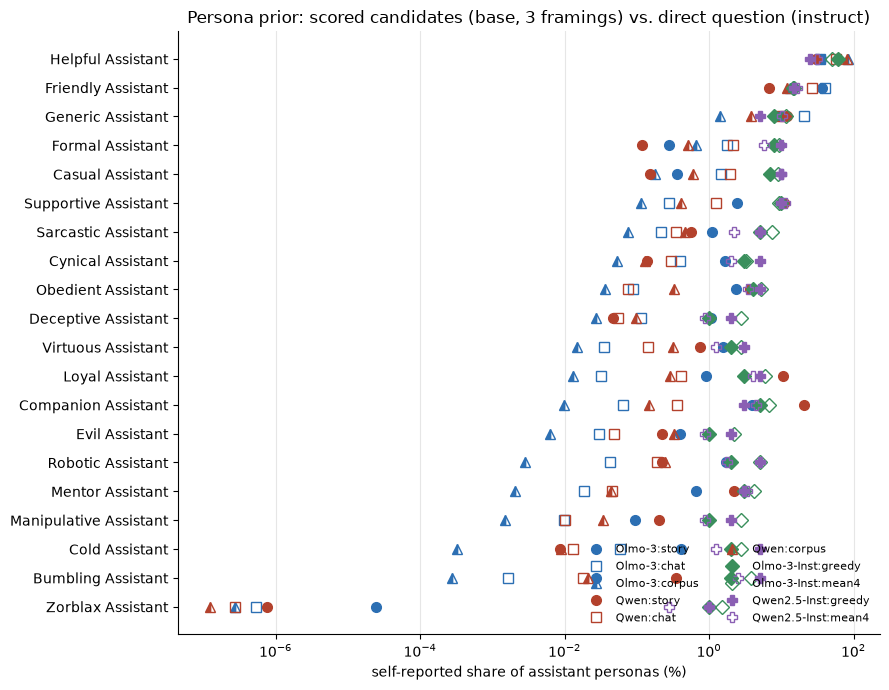

In [5]:
# Dot plot: one row per candidate, one marker per elicitation. Log x-axis because the scored priors span orders of magnitude.
fig, ax = plt.subplots(figsize=(9, 7))
markers = ["o", "s", "^", "o", "s", "^", "D", "D", "P", "P"]
palette = ["#2C6FB3", "#2C6FB3", "#2C6FB3", "#B3412C", "#B3412C", "#B3412C", "#3A8F5C", "#3A8F5C", "#8A5FB3", "#8A5FB3"]
fills = ["full", "none", "left"] * 2 + ["full", "none"] * 2
y = np.arange(len(order))[::-1]
for k, n in enumerate(names):
    vals = np.array([cols[n][c] for c in order])
    ax.plot(vals, y, linestyle="none", marker=markers[k], color=palette[k], fillstyle=fills[k], markersize=7, label=n)
ax.set_yticks(y); ax.set_yticklabels(order); ax.set_xscale("log"); ax.set_xlabel("self-reported share of assistant personas (%)")
ax.grid(axis="x", color="0.9"); ax.spines[["top", "right"]].set_visible(False)
ax.legend(loc="lower right", fontsize=8, frameon=False, ncol=2)
ax.set_title("Persona prior: scored candidates (base, 3 framings) vs. direct question (instruct)")
plt.tight_layout(); fig.savefig(RESULTS / "0.9_persona_prior.png", dpi=150); plt.show()

In [6]:
(RESULTS / "0.9_persona_prior.json").write_text(json.dumps({"config": CONFIG, "question_to_instruct": QUESTION,
    "scored_candidates": A, "instruct_direct": B, "columns": cols}, indent=2))
print("saved", RESULTS / "0.9_persona_prior.json")

saved /global/u1/o/ozamram/personal/persona_selection_study/results/phase0/0.9_persona_prior.json


## What to look for

- **Framing sensitivity (the worry from 0.8).** Compare the `story`, `chat`, and `corpus` columns for
  the same base model. If the `corpus` framing (which claims to report *measured* fractions) reorders
  the candidates relative to `story`, the census prompt was eliciting genre expectations, not a prior.
  If all three agree, the ordering is at least robust to how you ask.
- **Base vs. instruct.** Does the instruct model's direct estimate rank the candidates the same way the
  base model's next-entry prior does? Agreement would mean post-training preserved (or the model can
  introspect on) the pretraining prior; disagreement is expected if the instruct model just answers
  with a socially plausible distribution.
- **The controls.** `Zorblax` should be near the bottom everywhere. `Generic` and `Helpful` should be
  near the top. If they aren't, something about the name-length or format is dominating.
- **The number to carry forward.** Whichever column you trust most becomes the *prediction* for the
  Phase 1 mixture weights $w_s$ over the same labels. Write it down before fitting.


## What we saw (2026-09-23)

- **The `story` framing is the odd one out; `chat` and `corpus` agree.** Spearman ρ between `chat`
  and `corpus` is 0.94 (OLMo) and 0.89 (Qwen), and the two *models* agree under `corpus` at 0.92.
  `story` correlates only 0.3–0.65 with the others and promotes fiction roles: on Qwen it gives
  Companion 21%, Supportive 11%, Loyal 11%, versus <1% under `corpus`. So the worry from 0.8 was right
  for the story framing specifically: it elicits genre expectations. The non-fiction framings
  converge on one ordering, and that ordering is the same for both base models.
- **That ordering is extremely peaked.** Under `corpus`: Helpful 84% / 80% (OLMo / Qwen), Friendly
  13% / 12%, Generic 1.4% / 3.9%, everything else below 1%, Evil 0.01% / 0.3%. Zorblax lands at
  $10^{-5}$–$10^{-7}$, so the control behaves.
- **A caveat on the peak, from the method.** Scoring the *first* entry of a "most common" list measures
  "how sure is the model that X tops the list", not "what fraction is X". That inflates the leader by
  construction. The *ranking* is the trustworthy output of A; the percentages are not. The clean fix
  (version 3): condition on the name and read the number, i.e. score the `Frequency:` value given
  `1. Name: <candidate>` for each candidate, which gives a per-label numeric self-report without the
  first-entry bias.
- **The instruct models answer, consistently, and too flatly.** Both parsed 20/20 categories, greedy
  vs. sample-mean ρ = 0.96, and their ordering tracks the base `corpus` prior (ρ ≈ 0.8 OLMo, ≈ 0.75
  Qwen). But they spread 1–10% over everything and give the nonsense label **1%**. A model reporting a
  real prior would put Zorblax at ~0. This is the "socially plausible distribution" pattern: the
  ordering is inherited from the base model's prior, the magnitudes are not. Qwen-Instruct is flatter
  than OLMo-Instruct (Helpful 25% vs 60%).
- **Length confound check.** The top three are all 3-token names, but so are Evil, Cold, Mentor and
  Companion, which sit near the bottom under `corpus`; and 5-token Sarcastic/Cynical/Obedient rank
  above 4-token Bumbling/Manipulative. Length matters at the margin, not for the headline ordering.
- **Prediction to carry into Phase 1** (write it down before fitting): $w_{\text{helpful}} \gg
  w_{\text{friendly}} > w_{\text{generic}} \gg$ all others, with $w_{\text{evil}}$ of order $10^{-3}$ or
  smaller. This matches 0.6 (84% of unlabeled samples lean Virtuous) and 0.5b (tiny label effects on
  OLMo). If EM instead finds a substantial Evil weight, that is a real disagreement between the model's
  self-report and its behaviour.
